In [20]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset

In [21]:
# -------------------- Setup --------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [22]:
# -------------------- Load Data --------------------
df = pd.read_csv("Electric_Production.csv")
df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True)
df = df.sort_values("DATE").reset_index(drop=True)

series = df[["Value"]].astype(float).values

In [23]:
# -------------------- Roll Config --------------------
roll_no = "102317268"

window_size = (sum(int(d) for d in roll_no) % 10) + 8
prediction_horizon = (int(roll_no[-2:]) % 3) + 1
hidden_size = (int(roll_no[:3]) % 16) + 8

print(f"window={window_size}, horizon={prediction_horizon}, hidden={hidden_size}")

window=8, horizon=3, hidden=14


In [24]:
# -------------------- Scaling --------------------
train_cut = int(len(series) * 0.70)
val_cut = int(len(series) * 0.85)

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(series[:train_cut])
scaled_data = scaler.transform(series)

In [25]:
# -------------------- Sequence Creation --------------------
def create_sequences(data, window, horizon):
    X, y, idx = [], [], []
    for i in range(window, len(data) - horizon + 1):
        target_idx = i + horizon - 1
        X.append(data[i - window:i])
        y.append(data[target_idx])
        idx.append(target_idx)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(idx)

def split_data(X, y, idx):
    train_mask = idx < train_cut
    val_mask = (idx >= train_cut) & (idx < val_cut)
    test_mask = idx >= val_cut

    return (
        X[train_mask], y[train_mask],
        X[val_mask], y[val_mask],
        X[test_mask], y[test_mask],
    )

In [26]:
# -------------------- Dataset --------------------
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [27]:
# -------------------- Loaders --------------------
def make_loaders(window, horizon, batch_size=32):
    X, y, idx = create_sequences(scaled_data, window, horizon)
    Xtr, ytr, Xv, yv, Xt, yt = split_data(X, y, idx)

    train_dl = DataLoader(TSDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(TSDataset(Xv, yv), batch_size=batch_size)
    test_dl = DataLoader(TSDataset(Xt, yt), batch_size=batch_size)

    return train_dl, val_dl, test_dl

In [33]:
# -------------------- Models --------------------
class MLP(nn.Module):
    def __init__(self, window, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(window, hidden * 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

class GRUModel(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h[-1]).squeeze(-1)

class LSTMModel(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1]).squeeze(-1)

class TransformerModel(nn.Module):
    def __init__(self, hidden):
        super().__init__()

        # ✅ FIX: ensure divisibility
        n_heads = 2 if hidden % 2 == 0 else 1

        self.embed = nn.Linear(1, hidden)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=n_heads,
            dim_feedforward=hidden * 4,
            dropout=0.1,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze(-1)

In [34]:
# -------------------- Training --------------------
def train_model(model, train_dl, val_dl, lr=1e-3, epochs=120, patience=15):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = float("inf")
    best_state = None
    wait = 0

    history = {"train": [], "val": []}

    for _ in range(epochs):
        model.train()
        train_loss = 0

        for X, y in train_dl:
            X, y = X.to(device), y.to(device).squeeze(-1)

            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(X)

        train_loss /= len(train_dl.dataset)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(device), y.to(device).squeeze(-1)
                val_loss += loss_fn(model(X), y).item() * len(X)

        val_loss /= len(val_dl.dataset)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    return history

In [35]:
# -------------------- Evaluation --------------------
def inverse(x):
    return scaler.inverse_transform(np.array(x).reshape(-1, 1)).ravel()

def evaluate(model, loader):
    model.eval()
    preds, actual = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            preds.extend(model(X).cpu().numpy())
            actual.extend(y.numpy())

    actual = inverse(actual)
    preds = inverse(preds)

    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mse)

    return {"MSE": mse, "MAE": mae, "RMSE": rmse}, actual, preds

In [36]:
# -------------------- Plot Functions --------------------
def plot_loss(histories):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.ravel()

    for ax, (name, hist) in zip(axes, histories.items()):
        ax.plot(hist["train"], label="Train")
        ax.plot(hist["val"], label="Validation")
        ax.set_title(name)
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_predictions(actual, preds_dict):
    fig, axes = plt.subplots(len(preds_dict), 1, figsize=(14, 3 * len(preds_dict)))

    if len(preds_dict) == 1:
        axes = [axes]

    for ax, (name, pred) in zip(axes, preds_dict.items()):
        ax.plot(actual, label="Actual", linewidth=2)
        ax.plot(pred, label="Predicted", linewidth=1.5)
        ax.set_title(name)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [37]:
# -------------------- Run --------------------
train_dl, val_dl, test_dl = make_loaders(window_size, prediction_horizon)

models = {
    "MLP": MLP(window_size, hidden_size),
    "GRU": GRUModel(hidden_size),
    "LSTM": LSTMModel(hidden_size),
    "Transformer": TransformerModel(hidden_size),
}

histories = {}
predictions = {}
results = []
actual_vals = None

for name, model in models.items():
    model = model.to(device)

    lr = 8e-4 if name == "Transformer" else 1e-3

    hist = train_model(model, train_dl, val_dl, lr)
    metrics, actual, pred = evaluate(model, test_dl)

    histories[name] = hist
    predictions[name] = pred
    actual_vals = actual

    results.append({
        "Model": name,
        "MSE": metrics["MSE"],
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    })

    print(
        f"{name} -> MSE: {metrics['MSE']:.4f}, "
        f"MAE: {metrics['MAE']:.4f}, "
        f"RMSE: {metrics['RMSE']:.4f}"
    )


MLP -> MSE: 35.9204, MAE: 4.2986, RMSE: 5.9934
GRU -> MSE: 41.5984, MAE: 4.9595, RMSE: 6.4497
LSTM -> MSE: 44.7224, MAE: 5.1023, RMSE: 6.6875
Transformer -> MSE: 50.6707, MAE: 5.2297, RMSE: 7.1183


In [38]:
# -------------------- Results Table --------------------
df_results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("\nFinal Model Comparison:")
print(df_results.to_string(index=False))


Final Model Comparison:
      Model       MSE      MAE     RMSE
        MLP 35.920361 4.298577 5.993360
        GRU 41.598400 4.959451 6.449682
       LSTM 44.722412 5.102306 6.687482
Transformer 50.670696 5.229668 7.118335


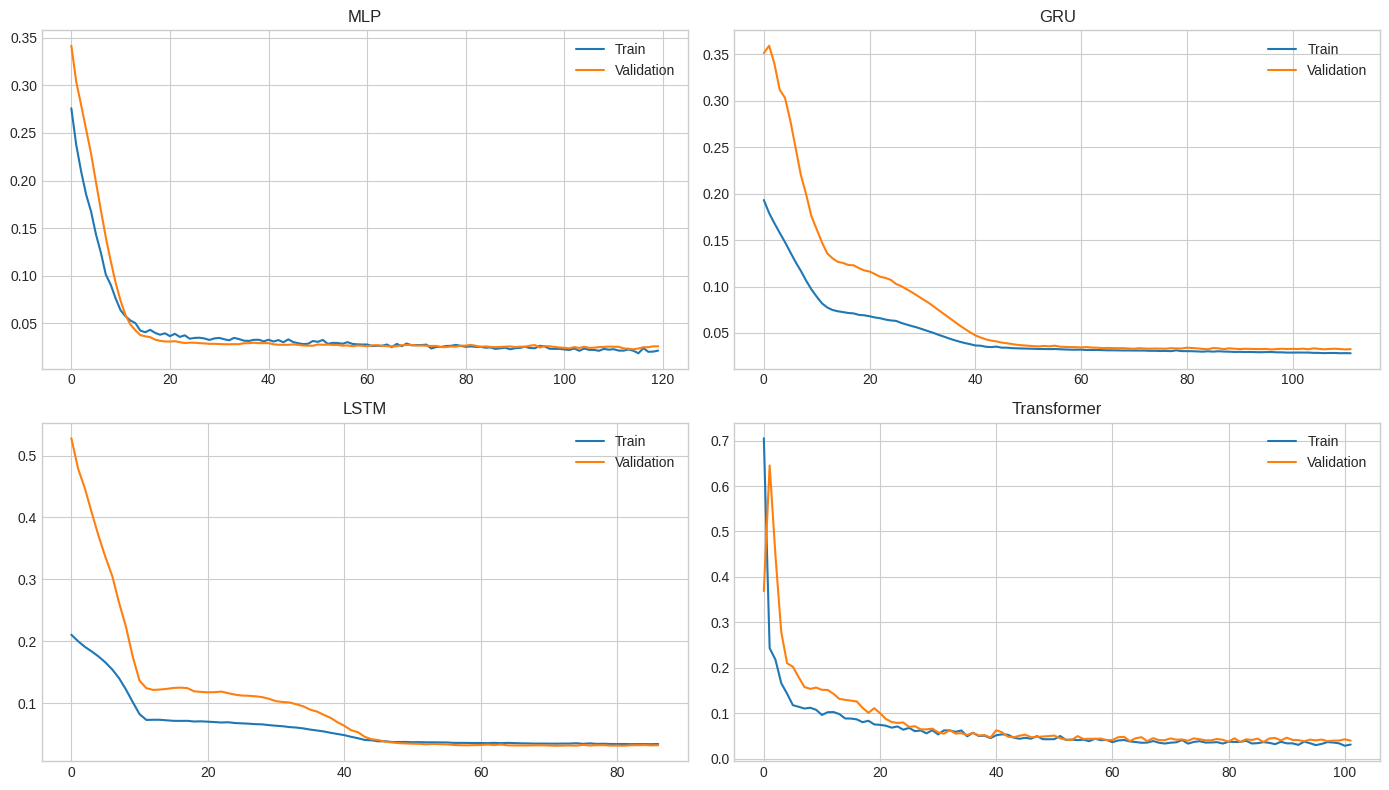

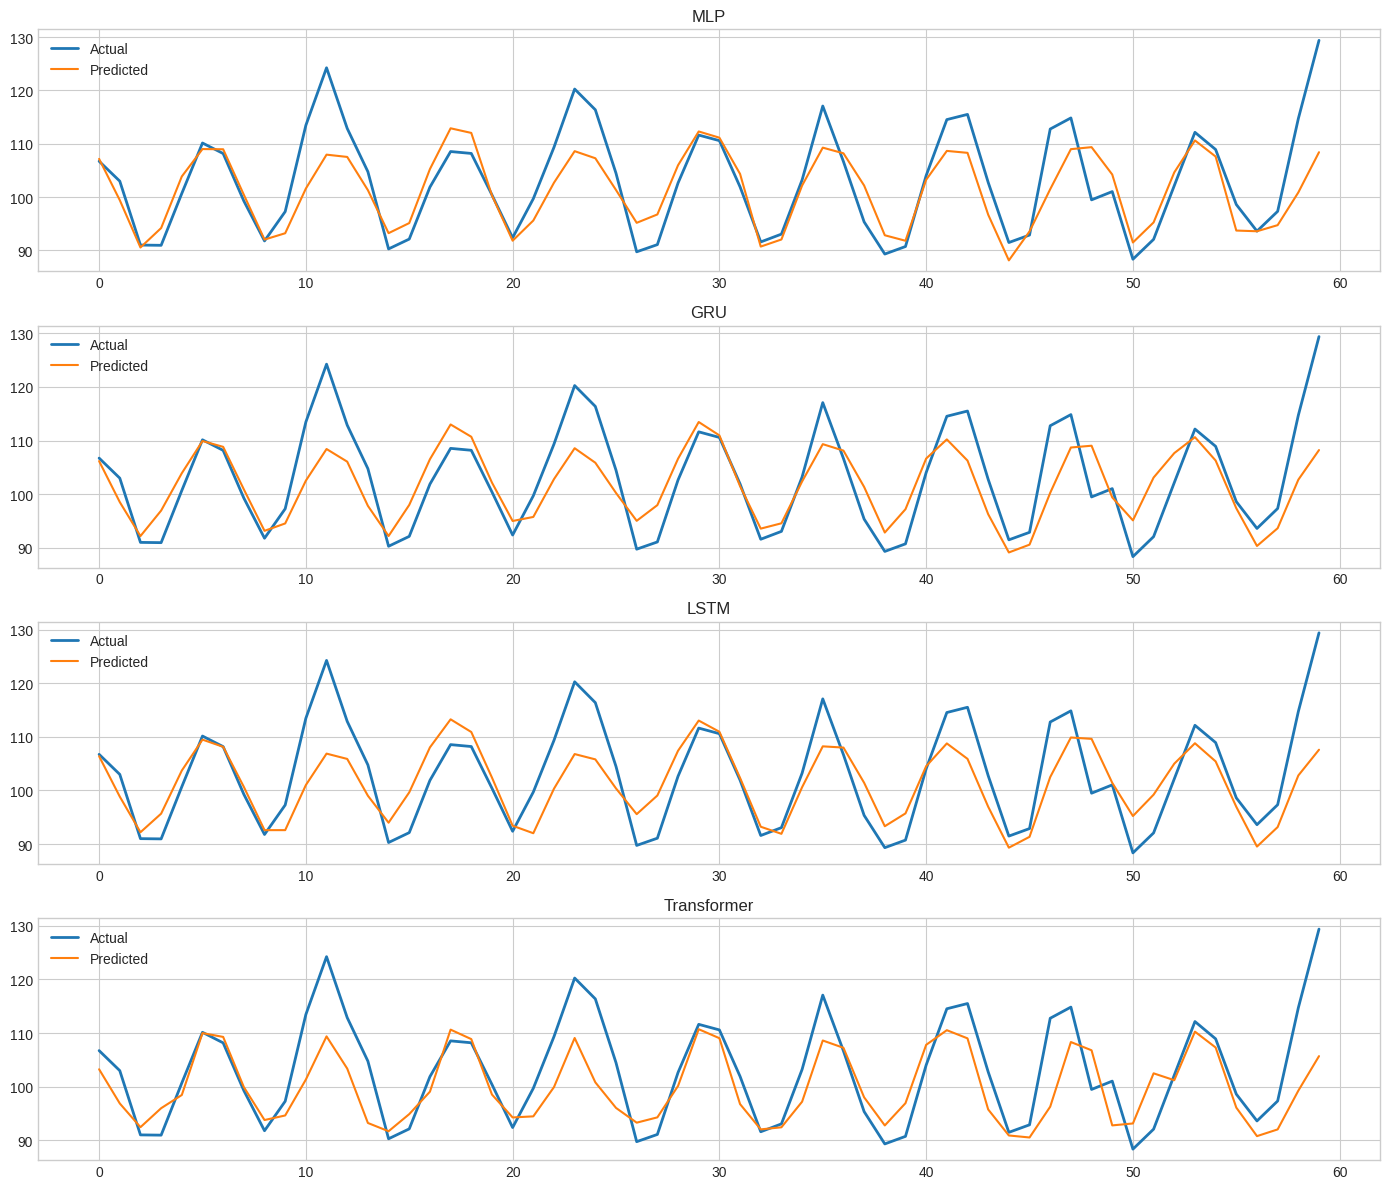

In [39]:
# -------------------- Plots --------------------
plot_loss(histories)
plot_predictions(actual_vals, predictions)

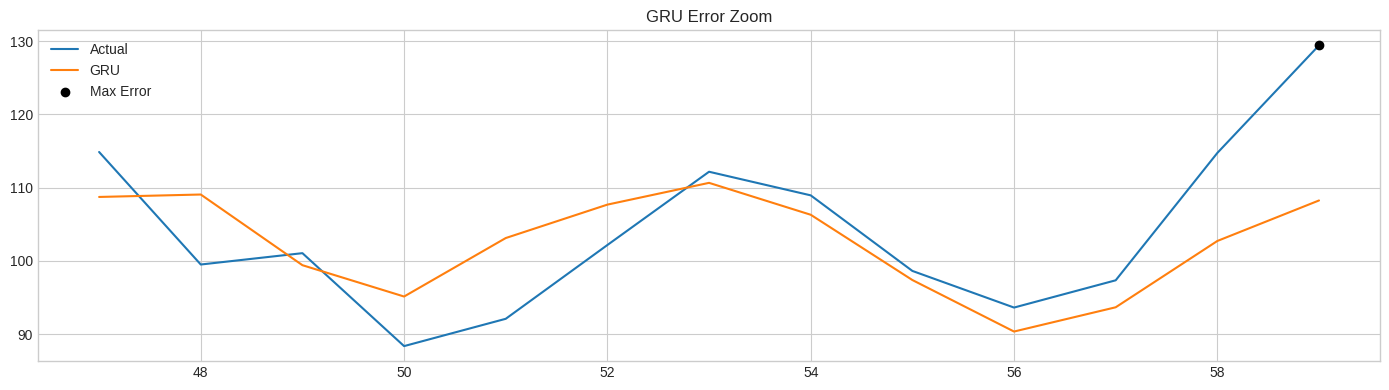

In [40]:
# -------------------- GRU Error Zoom --------------------
err = np.abs(actual_vals - predictions["GRU"])
idx = int(np.argmax(err))

start = max(0, idx - 12)
end = min(len(actual_vals), idx + 12)

plt.figure(figsize=(14, 4))
plt.plot(range(start, end), actual_vals[start:end], label="Actual")
plt.plot(range(start, end), predictions["GRU"][start:end], label="GRU")
plt.scatter([idx], [actual_vals[idx]], color="black", label="Max Error", zorder=5)

plt.title("GRU Error Zoom")
plt.legend()
plt.tight_layout()
plt.show()